In [1]:
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import astral
from astral import sun
from pandas.tseries.holiday import USFederalHolidayCalendar, get_calendar

# Import and merge direct download count data

In [2]:
bike_direct = pd.read_csv('../data/raw/bike.csv')
bike_direct["DateTime"] = bike_direct["DateTime"].apply(lambda x: datetime.datetime.strptime(x, '%m/%d/%Y %H:%M'))
bike_direct = bike_direct.rename(columns = {'DateTime':'Date',
                                           '<tspan>IN (In)</tspan>':'In (Bike)',
                                           '<tspan>OUT (Out)</tspan>':'Out (Bike)'})
bike_direct["Total (Bike)"] = bike_direct["In (Bike)"] + bike_direct["Out (Bike)"]
bike_direct = bike_direct.set_index("Date")

In [3]:
scooter_direct = pd.read_csv('../data/raw/scooter.csv')
scooter_direct["DateTime"] = scooter_direct["DateTime"].apply(lambda x: datetime.datetime.strptime(x, '%m/%d/%Y %H:%M'))
scooter_direct = scooter_direct.rename(columns = {'DateTime':'Date',
                                           '<tspan>IN (In)</tspan>':'In (Scooter)',
                                           '<tspan>OUT (Out)</tspan>':'Out (Scooter)'})
scooter_direct["Total (Scooter)"] = scooter_direct["In (Scooter)"] + scooter_direct["Out (Scooter)"]
scooter_direct = scooter_direct.set_index("Date")

In [4]:
counts_direct = pd.merge(bike_direct,
                         scooter_direct,
                         how="outer",
                         left_index=True,
                         right_index=True
                        )
counts_direct["In"] = counts_direct["In (Bike)"] + counts_direct["In (Scooter)"]
counts_direct["Out"] = counts_direct["Out (Bike)"] + counts_direct["Out (Scooter)"]
counts_direct["Total"] = counts_direct["Total (Bike)"] + counts_direct["Total (Scooter)"]

Our scraped counts for both bike and scooter match the direct download data, so that's good

### Merging day of week

In [5]:
counts_direct["Day of Week"] = counts_direct.index.day_name()

### Merging days of instruction and days of finals

In [6]:
finalsDates = pd.read_pickle('../data/date pkl/finalsDates.pkl')
instructionDates = pd.read_pickle('../data/date pkl/instructionDates.pkl')

# Filter to dates included in the data
finals_mask = (finalsDates <= counts_direct.index.max()) & (finalsDates >= counts_direct.index.min())
instruction_mask = (instructionDates <= counts_direct.index.max()) & (instructionDates >= counts_direct.index.min())
finalsDates = finalsDates[finals_mask]
instructionDates = instructionDates[instruction_mask]

# Make new column for whether a day is within the school year, a finals day, or neither
counts_direct["Academic Day"] = "Non-academic"
counts_direct.loc[finalsDates, "Academic Day"] = "Finals"
counts_direct.loc[instructionDates, "Academic Day"] = "Instruction"

### Merging holidays

Specifically only using holidays on the UC Davis academic calendar

In [7]:
holidayDates = pd.read_pickle('../data/date pkl/holidayDates.pkl')

# Filter to dates included in the data
holiday_mask = (holidayDates <= counts_direct.index.max()) & (holidayDates >= counts_direct.index.min())
holidayDates = holidayDates[holiday_mask]

# Make a new column for whether a day is a school holiday or not
counts_direct["Holiday"] = [index in holidayDates for index in counts_direct.index]

### Merging hours of daylight

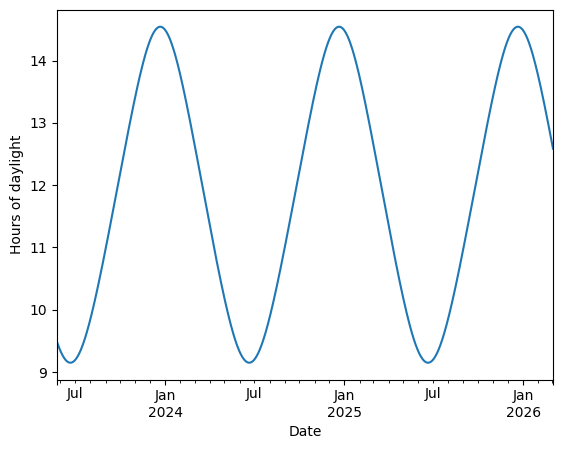

In [8]:
def find_hours_daylight(datetime):
    # Create observer object at Davis bike counter location
    observer = astral.Observer(latitude=38.544406,
                           longitude=-121.74263)
    timedelta = astral.sun.sunrise(observer, datetime) - astral.sun.sunset(observer, datetime)
    seconds = timedelta.total_seconds()
    hours = seconds / 3600
    return hours

hours_of_daylight = []
for index in counts_direct.index:
    hours_of_daylight.append(find_hours_daylight(index))
hours_of_daylight

counts_direct["Hours of daylight"] = hours_of_daylight
counts_direct["Hours of daylight"].plot()
plt.ylabel('Hours of daylight');

### Merging Temperature

In [9]:
temperature = pd.read_csv("../data/raw/temperature.csv")
temperature = temperature[["DATE", "PRCP", "TMAX", "TMIN"]]
temperature = temperature.rename(columns={'DATE': 'Date',
                                          'PRCP': 'Precipitation',
                                          'TMAX': 'Max temperature',
                                          'TMIN': 'Min temperature'
                                         })
temperature["Date"] = temperature["Date"].apply(lambda x: datetime.datetime.strptime(x, '%Y-%m-%d'))
temperature = temperature.set_index('Date')

merged_data_direct = pd.merge(counts_direct,
                              temperature,
                              how='inner',
                              left_index=True,
                              right_index=True
                             )

### Resampling dataset to weekly counts

Counts were resampled using summation. Other columns had different aggregation functions:
- Academic Day: used the most common value (mode), e.g. if most days were finals days, that week was considered a finals week
- Holiday: if any day during that week was a holiday, that week was considered a holiday week
- Hours of daylight: used the mean value

In [10]:
counts_direct_weekly = counts_direct.resample("W-MON", label='left').agg(
    In_Bike=('In (Bike)','sum'),
    Out_Bike=('Out (Bike)','sum'),
    Total_Bike=('Total (Bike)','sum'),
    In_Scooter=('In (Scooter)','sum'),
    Out_Scooter=('Out (Scooter)','sum'),
    Total_Scooter=('Total (Scooter)','sum'),
    In=('In','sum'),
    Out=('Out','sum'),
    Total=('Total','sum'),
    Academic_Day=('Academic Day',pd.Series.mode),
    Holiday=('Holiday','any'),
    Hours_of_daylight=('Hours of daylight','mean')
)

counts_direct_weekly = counts_direct_weekly.rename(columns={
    'In_Bike':'In (Bike)',
    'Out_Bike':'Out (Bike)',
    'Total_Bike':'Total (Bike)',
    'In_Scooter':'In (Scooter)',
    'Out_Scooter':'Out (Scooter)',
    'Total_Scooter':'Total (Scooter)',
    'Academic_Day':'Academic Day (Mode)',
    'Holiday':'Holiday (Any)',
    'Hours_of_daylight':'Hours of daylight (Mean)',
})

In [11]:
temperature_weekly = temperature.resample("W-MON", label="left").agg(
    Precipitation_sum=('Precipitation', 'sum'),
    Max_temperature_max=('Max temperature', 'max'),
    Max_temperature_mean=('Max temperature', 'mean'),
    Min_temperature_min=('Min temperature', 'min'),
    Min_temperature_mean=('Min temperature', 'mean')
)
temperature_weekly = temperature_weekly.rename(columns={
    'Precipitation_sum': 'Precipitation (sum)',
    'Max_temperature_max':'Max temperature (max)',
    'Max_temperature_mean':'Max temperature (mean)',
    'Min_temperature_min':'Min temperature (min)',
    'Min_temperature_mean':'Min temperature (mean)'
})

In [12]:
merged_data_direct_weekly = pd.merge(counts_direct_weekly,
                                     temperature_weekly,
                                     how='inner',
                                     left_index=True,
                                     right_index=True
                                    )

### Filter dataset to relevant dates
Filter down to dates in 2024 and 2025 for full years of data--do note that for our weekly data, the date listed is the first day of that week. The first week available is only 1/7/2024, and we could manually add the week of 12/31/2023 if we want? We also have the week of 12/28/2025 even though some of the later days of that week spills over into 2026.

In [13]:
dateMask = (merged_data_direct.index >= datetime.datetime(2024, 1, 1)) & (merged_data_direct.index <= datetime.datetime(2025, 12, 31))
dateMask_weekly = (merged_data_direct_weekly.index >= datetime.datetime(2024, 1, 1)) & (merged_data_direct_weekly.index <= datetime.datetime(2025, 12, 31))

merged_data_direct = merged_data_direct[dateMask]
merged_data_direct_weekly = merged_data_direct_weekly[dateMask_weekly]

In [14]:
display(merged_data_direct.head(), merged_data_direct_weekly.head())

,In (Bike),Out (Bike),Total (Bike),In (Scooter),Out (Scooter),Total (Scooter),In,Out,Total,Day of Week,Academic Day,Holiday,Hours of daylight,Precipitation,Max temperature,Min temperature
Date,,,,,,,,,,,,,,,,
2024-01-01,127,111,238,38,31,69,165,142,307,Monday,Non-academic,True,14.489649,0.00,60.0,41.0
2024-01-02,128,158,286,25,49,74,153,207,360,Tuesday,Non-academic,False,14.478673,0.00,64.0,44.0
2024-01-03,196,207,403,33,39,72,229,246,475,Wednesday,Non-academic,False,14.466712,0.37,55.0,42.0
2024-01-04,232,244,476,56,48,104,288,292,580,Thursday,Non-academic,False,14.453779,0.01,61.0,36.0
2024-01-05,260,292,552,53,41,94,313,333,646,Friday,Non-academic,False,14.439885,0.00,63.0,39.0


,In (Bike),Out (Bike),Total (Bike),In (Scooter),Out (Scooter),Total (Scooter),In,Out,Total,Academic Day (Mode),Holiday (Any),Hours of daylight (Mean),Precipitation (sum),Max temperature (max),Max temperature (mean),Min temperature (min),Min temperature (mean)
Date,,,,,,,,,,,,,,,,,
2024-01-01,2471,2566,5037,447,434,881,2918,3000,5918,Non-academic,False,14.437990,0.62,64.0,59.571429,36.0,39.571429
2024-01-08,5515,5072,10587,927,738,1665,6442,5810,12252,Instruction,True,14.315209,0.24,60.0,57.285714,36.0,38.285714
2024-01-15,5269,4885,10154,983,749,1732,6252,5634,11886,Instruction,False,14.151409,1.80,66.0,62.428571,38.0,43.428571
2024-01-22,6195,5707,11902,1096,846,1942,7291,6553,13844,Instruction,False,13.952816,0.37,72.0,65.714286,33.0,44.857143
2024-01-29,5185,4782,9967,980,772,1752,6165,5554,11719,Instruction,False,13.725932,3.53,73.0,65.142857,42.0,46.000000


# Create pivot tables for weekly distributions

In [15]:
# Add beginning of week to daily counts so that it can be pivot tabled
merged_data_direct["Week Start"] = pd.Series(
    merged_data_direct.index.to_period('W-SUN',),
    index=merged_data_direct.index
).apply(lambda x: x.start_time)

## Pivot table for PCA

In [16]:
# Create pivot table
week_distributions = merged_data_direct.pivot_table(
    ['Total (Bike)','Total (Scooter)'],
    index=merged_data_direct["Week Start"],
    columns=merged_data_direct["Day of Week"],
    fill_value=np.nan,
)

# Remove weeks with NaN values, which would only be the first and last week of the year where some values are in the previous/next year
week_distributions = week_distributions.dropna()

# Cast to integer values
week_distributions = week_distributions.astype(np.int64)

# Reorder columns so that they match order of days in the week
week_distributions = week_distributions[[
    ('Total (Bike)',    'Monday'),
    ('Total (Bike)',   'Tuesday'),
    ('Total (Bike)', 'Wednesday'),
    ('Total (Bike)',  'Thursday'),
    ('Total (Bike)',    'Friday'),
    ('Total (Bike)',  'Saturday'),
    ('Total (Bike)',    'Sunday'),
    ('Total (Scooter)',    'Monday'),
    ('Total (Scooter)',   'Tuesday'),
    ('Total (Scooter)', 'Wednesday'),
    ('Total (Scooter)',  'Thursday'),
    ('Total (Scooter)',    'Friday'),
    ('Total (Scooter)',  'Saturday'),
    ('Total (Scooter)',    'Sunday'),

]]

# Flatten the column names to avoid MultiIndex
# week_distributions.columns = week_distributions.columns.droplevel()
week_distributions.columns = [' '.join(col).strip() for col in week_distributions.columns.values]

In [17]:
week_distributions.columns

Index(['Total (Bike) Monday', 'Total (Bike) Tuesday', 'Total (Bike) Wednesday',
       'Total (Bike) Thursday', 'Total (Bike) Friday', 'Total (Bike) Saturday',
       'Total (Bike) Sunday', 'Total (Scooter) Monday',
       'Total (Scooter) Tuesday', 'Total (Scooter) Wednesday',
       'Total (Scooter) Thursday', 'Total (Scooter) Friday',
       'Total (Scooter) Saturday', 'Total (Scooter) Sunday'],
      dtype='str')

In [18]:
display(week_distributions)

,Total (Bike) Monday,Total (Bike) Tuesday,Total (Bike) Wednesday,Total (Bike) Thursday,Total (Bike) Friday,Total (Bike) Saturday,Total (Bike) Sunday,Total (Scooter) Monday,Total (Scooter) Tuesday,Total (Scooter) Wednesday,Total (Scooter) Thursday,Total (Scooter) Friday,Total (Scooter) Saturday,Total (Scooter) Sunday
Week Start,,,,,,,,,,,,,,
2024-01-01,238,286,403,476,552,384,844,69,74,72,104,94,64,169
2024-01-08,2092,2065,2099,2108,1818,615,924,304,309,329,351,279,109,131
2024-01-15,958,1419,1989,2122,1713,666,795,157,244,356,348,281,101,144
2024-01-22,1450,2056,1214,2034,1829,1462,1357,258,298,197,346,314,256,224
2024-01-29,1950,2132,1060,1854,1758,1250,322,307,392,164,329,311,244,72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-24,1401,1284,785,203,245,356,413,494,408,281,84,110,142,196
2025-12-01,1364,1541,1588,1507,1407,942,753,433,549,549,515,447,392,336
2025-12-08,986,1152,1118,1014,997,410,192,371,360,384,345,370,199,94


### PCA with only numerical values

In [19]:
from sklearn.decomposition import PCA

In [20]:
x = week_distributions.values
x.shape

(104, 14)

In [21]:
PCAfit = PCA(0.9)
xPCA = PCAfit.fit_transform(x)
display(xPCA.shape, PCAfit.explained_variance_ratio_)

(104, 3)

array([0.8333743 , 0.06181801, 0.02956588])

In [22]:
xPCA

array([[-2.42403907e+03, -5.48920422e+02,  1.86414153e+02],
       [ 1.06913546e+03,  6.21081342e+02, -3.83753185e+02],
       [ 3.02604614e+02, -3.55068422e+02, -7.69075975e+02],
       [ 7.89292596e+02, -2.93506620e+02,  6.00878120e+02],
       [ 5.36065657e+02,  5.35519912e+02,  3.74757034e+02],
       [ 4.46251248e+02,  8.76907696e+01,  5.38507242e+02],
       [ 3.38590319e+02,  5.63903536e+02, -2.56403573e+02],
       [ 3.47630870e+02, -1.34053500e+03,  2.06626668e+01],
       [ 2.08287929e+02,  6.30112180e+02,  5.38896646e+01],
       [ 1.03710407e+03, -1.74245332e+02,  1.06747183e+02],
       [ 1.02792984e+03, -4.37427088e+02,  4.83340225e+02],
       [-3.09534504e+02,  6.45358250e+02, -4.37317653e+02],
       [-2.07518045e+03, -2.48725190e+00,  3.66572986e+02],
       [ 1.05431798e+03,  4.91052370e+02,  4.77464203e+02],
       [ 1.25493231e+03,  5.15261133e+02, -4.73867078e+02],
       [ 2.00450468e+03, -2.43105038e+02,  4.08377864e+02],
       [ 1.46688722e+03,  1.41590925e+02

In [23]:
# AI generated code to compute correlation of original variables with principal components
pc_cols = [f"PC{i+1}" for i in range(min(3, xPCA.shape[1]))]
pc_df = pd.DataFrame(xPCA[:, :len(pc_cols)], index=week_distributions.index, columns=pc_cols)

# Keep only original pivot variables and exclude derived columns like Cluster
orig_cols = [col for col in week_distributions.columns if col.startswith("Total ")]
orig_df = week_distributions[orig_cols]

# Correlation of each original variable with each principal component
pc_orig_corr = pd.concat([orig_df, pc_df], axis=1).corr().loc[orig_cols, pc_cols]
pc_orig_corr

,PC1,PC2,PC3
Total (Bike) Monday,0.865005,0.453860,0.123133
Total (Bike) Tuesday,0.940185,0.235273,0.086297
Total (Bike) Wednesday,0.943221,-0.004881,-0.222680
Total (Bike) Thursday,0.953088,-0.076417,-0.114369
Total (Bike) Friday,0.956698,-0.197761,-0.052309
Total (Bike) Saturday,0.863923,-0.328687,0.333416
Total (Bike) Sunday,0.850438,-0.314693,0.277014
Total (Scooter) Monday,0.727385,0.300772,0.012511
Total (Scooter) Tuesday,0.807684,0.155131,-0.037432
Total (Scooter) Wednesday,0.786147,-0.050130,-0.278080


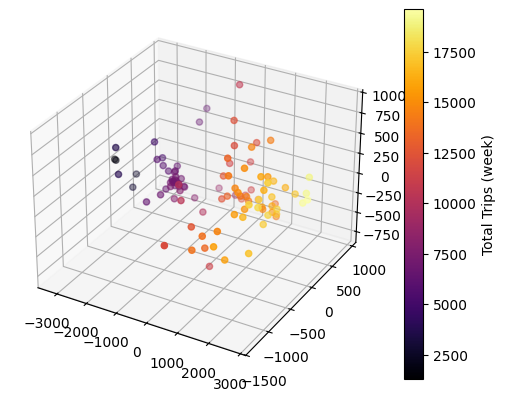

In [24]:
total_trips = x.sum(1)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
p = ax.scatter(xPCA[:, 0], xPCA[:, 1], xPCA[:, 2], c=total_trips, cmap='inferno')
fig.colorbar(p, label='Total Trips (week)');

### Unsupervised Clustering

In [25]:
from sklearn.mixture import GaussianMixture

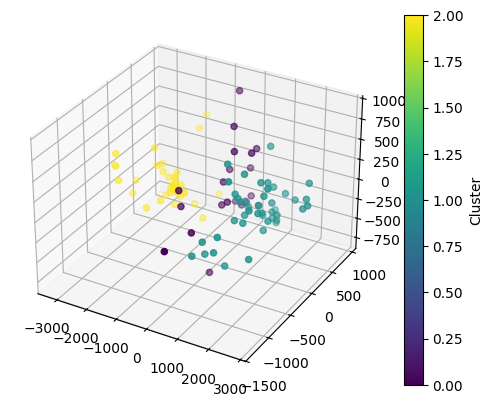

In [26]:
gmm = GaussianMixture(3, covariance_type='full', random_state=0)
gmm.fit(xPCA)

cluster_label = gmm.predict(xPCA)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
p = ax.scatter(xPCA[:, 0], xPCA[:, 1], xPCA[:, 2], c=cluster_label, cmap='viridis')

fig.colorbar(p, ax=ax, label="Cluster")

In [27]:
week_distributions['Cluster'] = cluster_label

### Visualization

In [28]:
plotDF = pd.DataFrame(week_distributions['Cluster'], index=week_distributions.index)
plotDF["Monday"] = week_distributions["Total (Bike) Monday"] + week_distributions["Total (Scooter) Monday"]
plotDF["Tuesday"] = week_distributions["Total (Bike) Tuesday"] + week_distributions["Total (Scooter) Tuesday"]
plotDF["Wednesday"] = week_distributions["Total (Bike) Wednesday"] + week_distributions["Total (Scooter) Wednesday"]
plotDF["Thursday"] = week_distributions["Total (Bike) Thursday"] + week_distributions["Total (Scooter) Thursday"]
plotDF["Friday"] = week_distributions["Total (Bike) Friday"] + week_distributions["Total (Scooter) Friday"]
plotDF["Saturday"] = week_distributions["Total (Bike) Saturday"] + week_distributions["Total (Scooter) Saturday"]
plotDF["Sunday"] = week_distributions["Total (Bike) Sunday"] + week_distributions["Total (Scooter) Sunday"]

In [29]:
plotDF

,Cluster,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
Week Start,,,,,,,,
2024-01-01,2,307,360,475,580,646,448,1013
2024-01-08,1,2396,2374,2428,2459,2097,724,1055
2024-01-15,0,1115,1663,2345,2470,1994,767,939
2024-01-22,1,1708,2354,1411,2380,2143,1718,1581
2024-01-29,0,2257,2524,1224,2183,2069,1494,394
...,...,...,...,...,...,...,...,...
2025-11-24,2,1895,1692,1066,287,355,498,609
2025-12-01,0,1797,2090,2137,2022,1854,1334,1089
2025-12-08,2,1357,1512,1502,1359,1367,609,286


In [30]:
plotDF = plotDF.join(merged_data_direct_weekly[["Academic Day (Mode)","Holiday (Any)"]])

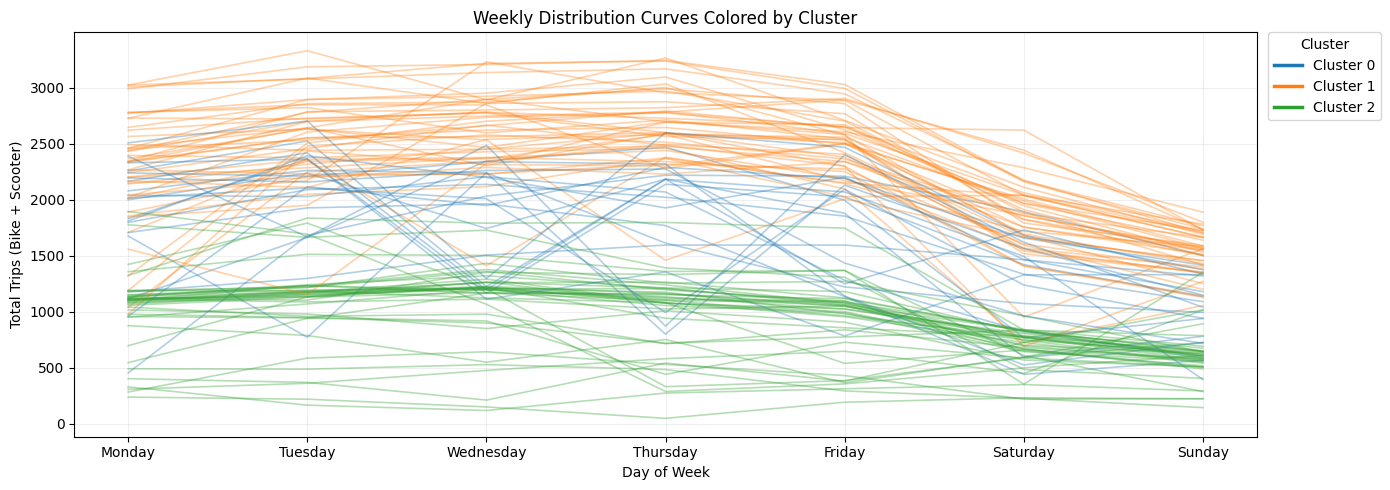

In [31]:
day_cols = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

clusters = plotDF["Cluster"]
unique_clusters = sorted(clusters.dropna().unique())

cmap = plt.get_cmap("tab10")
cluster_colors = {cluster: cmap(i % cmap.N) for i, cluster in enumerate(unique_clusters)}

fig, ax = plt.subplots(1, 1, figsize=(14, 5))

for _, row in plotDF.iterrows():
    cluster = row["Cluster"]
    ax.plot(
        day_cols,
        row[day_cols].to_numpy(),
        color=cluster_colors.get(cluster, "gray"),
        alpha=0.35,
        linewidth=1.2,
    )

for cluster, color in cluster_colors.items():
    ax.plot([], [], color=color, linewidth=2.5, label=f"Cluster {int(cluster)}")

ax.set_title("Weekly Distribution Curves Colored by Cluster")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Total Trips (Bike + Scooter)")
ax.legend(title="Cluster", loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
ax.grid(alpha=0.2)
plt.tight_layout()

In [32]:
plotDF[plotDF["Cluster"] == 0]

,Cluster,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday,Academic Day (Mode),Holiday (Any)
Week Start,,,,,,,,,,
2024-01-15,0,1115,1663,2345,2470,1994,767,939,Instruction,False
2024-01-29,0,2257,2524,1224,2183,2069,1494,394,Instruction,False
2024-02-05,0,1831,2365,1165,2138,2026,1420,1134,Instruction,False
2024-02-12,0,1999,2237,1743,2183,1879,593,780,Instruction,True
2024-02-19,0,453,1681,2032,2219,2210,1893,1503,Instruction,False
2024-02-26,0,2079,2262,2240,1613,1221,1073,994,Instruction,False
2024-03-18,0,1706,1927,1963,1769,1135,440,566,Finals,False
2024-06-10,0,2039,2028,2206,2069,1281,825,585,Non-academic,False
2024-09-16,0,1178,1297,1505,1595,1595,1463,1319,Non-academic,False


In [33]:
plotDF[plotDF["Cluster"] == 1]

,Cluster,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday,Academic Day (Mode),Holiday (Any)
Week Start,,,,,,,,,,
2024-01-08,1,2396,2374,2428,2459,2097,724,1055,Instruction,True
2024-01-22,1,1708,2354,1411,2380,2143,1718,1581,Instruction,False
2024-03-04,1,1889,2209,2231,2317,2275,1605,1380,Instruction,False
2024-03-11,1,1855,2048,2117,2368,2028,2039,1705,Instruction,False
2024-04-01,1,2565,2630,2535,1459,2008,1666,1454,Instruction,False
2024-04-08,1,2341,2554,2563,2600,2300,689,1270,Instruction,False
2024-04-15,1,2455,2533,2662,2793,2644,2622,1729,Instruction,False
2024-04-22,1,2492,2441,2451,2478,2340,1756,1512,Instruction,False
2024-04-29,1,2367,2634,2467,2697,2583,950,1563,Instruction,False


In [34]:
plotDF[plotDF["Cluster"] == 2]

,Cluster,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday,Academic Day (Mode),Holiday (Any)
Week Start,,,,,,,,,,
2024-01-01,2,307,360,475,580,646,448,1013,Non-academic,False
2024-03-25,2,875,787,549,751,365,595,892,Non-academic,True
2024-06-17,2,1016,979,849,1008,906,568,507,Non-academic,True
2024-06-24,2,1134,1240,1321,1209,1061,650,516,Non-academic,False
2024-07-01,2,977,947,917,440,727,586,507,Non-academic,True
2024-07-08,2,1068,1152,1217,941,856,777,603,Non-academic,False
2024-07-15,2,1135,1176,1290,1081,955,725,539,Non-academic,False
2024-07-22,2,1112,1087,1112,1024,1050,780,640,Non-academic,False
2024-07-29,2,1188,1217,1359,1195,1093,667,488,Non-academic,False


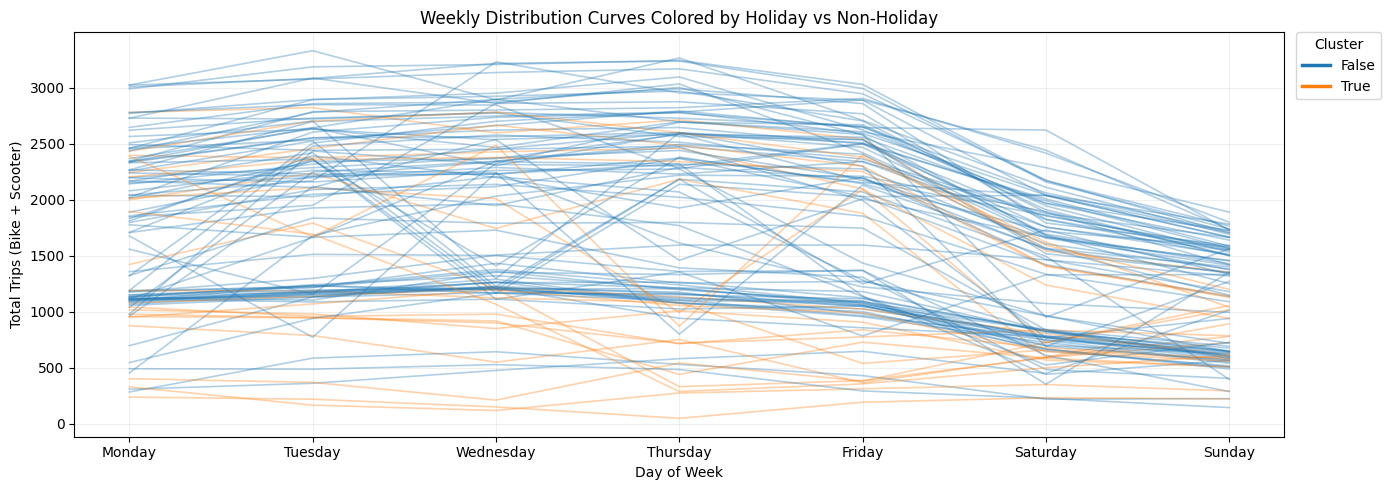

In [35]:
day_cols = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

clusters = plotDF["Holiday (Any)"]
unique_clusters = sorted(clusters.dropna().unique())

cmap = plt.get_cmap("tab10")
cluster_colors = {cluster: cmap(i % cmap.N) for i, cluster in enumerate(unique_clusters)}

fig, ax = plt.subplots(1, 1, figsize=(14, 5))

for _, row in plotDF.iterrows():
    cluster = row["Holiday (Any)"]
    ax.plot(
        day_cols,
        row[day_cols].to_numpy(),
        color=cluster_colors.get(cluster, "gray"),
        alpha=0.35,
        linewidth=1.2,
    )

for cluster, color in cluster_colors.items():
    ax.plot([], [], color=color, linewidth=2.5, label=cluster)

ax.set_title("Weekly Distribution Curves Colored by Holiday vs Non-Holiday")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Total Trips (Bike + Scooter)")
ax.legend(title="Cluster", loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
ax.grid(alpha=0.2)
plt.tight_layout()

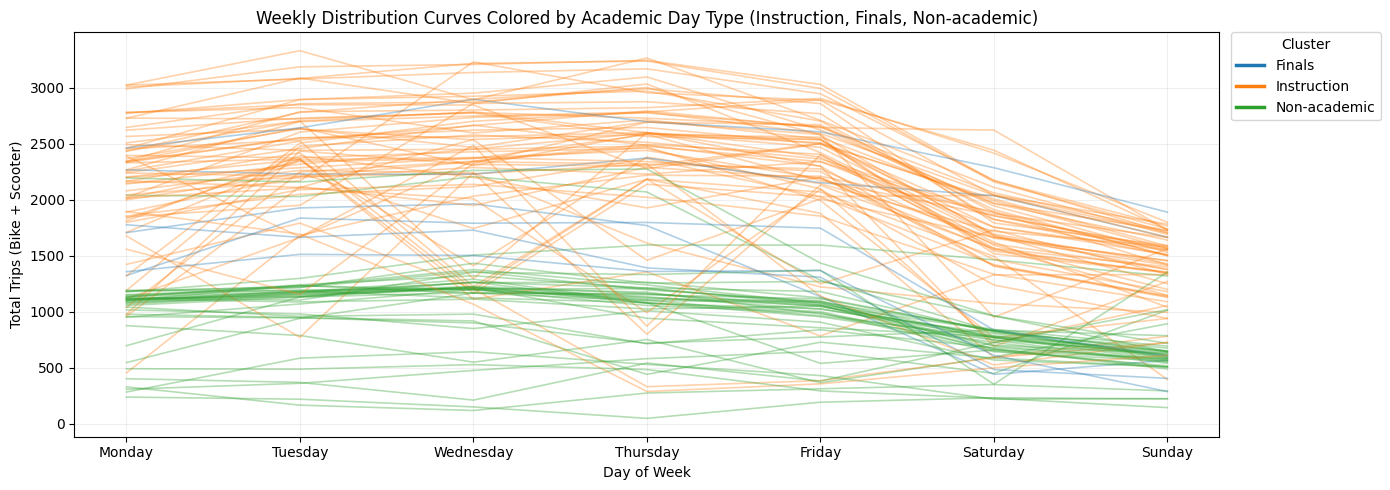

In [36]:
day_cols = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

clusters = plotDF["Academic Day (Mode)"]
unique_clusters = sorted(clusters.dropna().unique())

cmap = plt.get_cmap("tab10")
cluster_colors = {cluster: cmap(i % cmap.N) for i, cluster in enumerate(unique_clusters)}

fig, ax = plt.subplots(1, 1, figsize=(14, 5))

for _, row in plotDF.iterrows():
    cluster = row["Academic Day (Mode)"]
    ax.plot(
        day_cols,
        row[day_cols].to_numpy(),
        color=cluster_colors.get(cluster, "gray"),
        alpha=0.35,
        linewidth=1.2,
    )

for cluster, color in cluster_colors.items():
    ax.plot([], [], color=color, linewidth=2.5, label=cluster)

ax.set_title("Weekly Distribution Curves Colored by Academic Day Type (Instruction, Finals, Non-academic)")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Total Trips (Bike + Scooter)")
ax.legend(title="Cluster", loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
ax.grid(alpha=0.2)
plt.tight_layout()

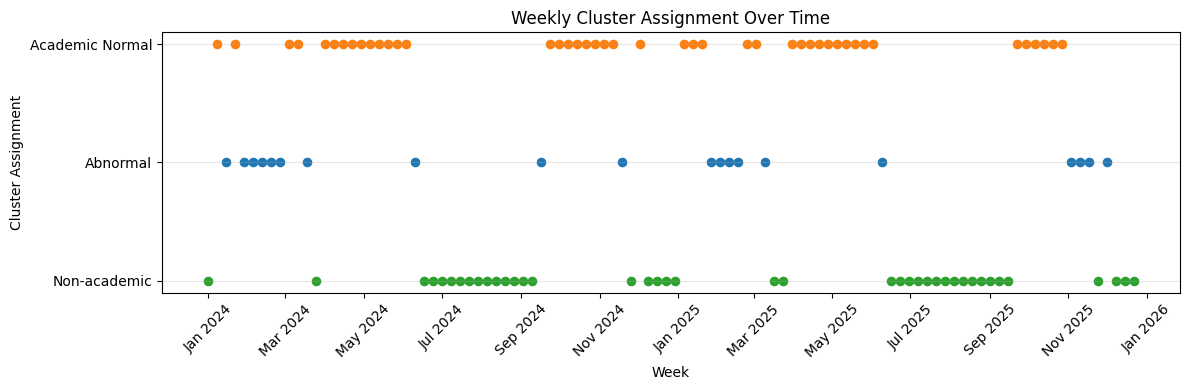

In [37]:
import matplotlib.dates as mdates

weeks = week_distributions.index
clusters = week_distributions['Cluster']
unique_clusters = sorted(clusters.dropna().unique())

cluster_name_map = {
    0: 'Abnormal',
    1: 'Academic Normal',
    2: 'Non-academic',
}

# Custom y-axis order: bottom Non-academic, middle Abnormal, top Academic Normal
display_pos_map = {
    2: 0,
    0: 1,
    1: 2,
}

cmap = plt.get_cmap('tab10')
colors = {c: cmap(i % cmap.N) for i, c in enumerate(unique_clusters)}

plt.figure(figsize=(12, 4))

for c in unique_clusters:
    mask = clusters == c
    yvals = np.full(mask.sum(), display_pos_map.get(int(c), int(c)))
    label_name = cluster_name_map.get(int(c), f'Cluster {int(c)}')
    plt.scatter(weeks[mask], yvals, color=colors[c], s=35, label=label_name)

ordered_positions = [0, 1, 2]
ordered_labels = ['Non-academic', 'Abnormal', 'Academic Normal']
plt.yticks(ordered_positions, ordered_labels)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xlabel('Week')
plt.ylabel('Cluster Assignment')
plt.title('Weekly Cluster Assignment Over Time')
plt.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()